# Notebook Cell Index and Descriptions

**Cell 1 (Markdown):**
- This cell provides an index and description of each code cell in the notebook.
- The library that is used in this notebook is Meep(MIT Electromagnetic Equation Propagation) which is an open-source software package for simulating electromagnetic systems using the finite-difference time-domain (FDTD) method. os, io, numpy, matplotlib, PIL are other libraries used for file handling, numerical operations, plotting and image processing respectively.

**Cell 2 (Code):**
- Outputs: Band structure plot of Tight binding model with band gap
- 
**cell 3 (Code):**
- Outputs: Two plots of optical band stucture where the lattice constant was scaled from nanometer to micrometer which takes from 100 THz to 1 THz region. 
- 






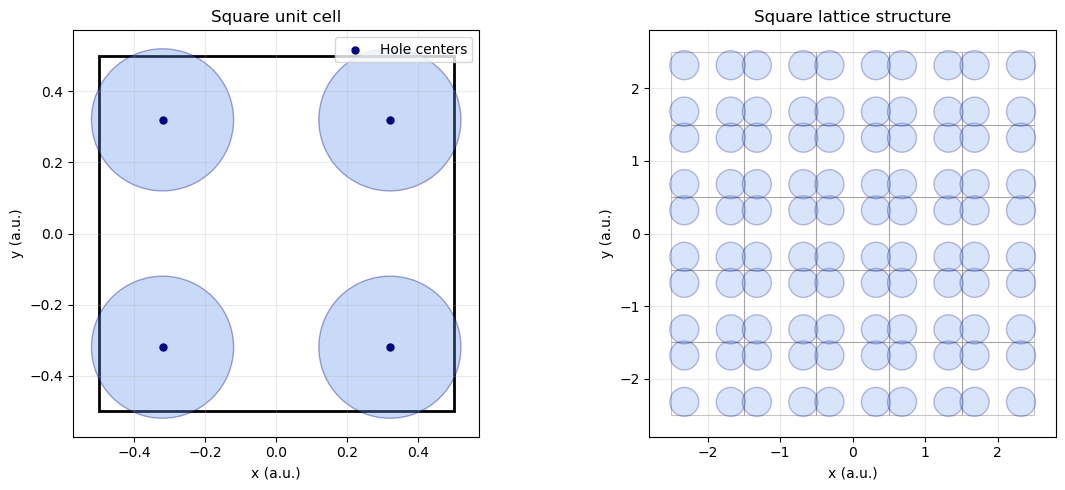

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# -------------------------------------------------
# Square-lattice geometry visualization
# -------------------------------------------------
a = 1.0
offset = 0.32 * a
r = 0.2 * a

motif = np.array([
    [+offset, +offset],
    [+offset, -offset],
    [-offset, +offset],
    [-offset, -offset],
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unit cell
ax = axes[0]
ax.add_patch(Rectangle((-0.5 * a, -0.5 * a), a, a, fill=False, lw=2.0, ec='black'))
for x, y in motif:
    ax.add_patch(Circle((x, y), r, fc='cornflowerblue', ec='navy', alpha=0.35))
ax.scatter(motif[:, 0], motif[:, 1], c='navy', s=25, label='Hole centers')
ax.set_title('Square unit cell')
ax.set_xlabel('x (a.u.)')
ax.set_ylabel('y (a.u.)')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25)
ax.legend(loc='upper right')

# Lattice tiling
ax = axes[1]
N = 2
for i in range(-N, N + 1):
    for j in range(-N, N + 1):
        shift = np.array([i * a, j * a])
        ax.add_patch(Rectangle((-0.5 * a + shift[0], -0.5 * a + shift[1]), a, a,
                               fill=False, lw=0.8, ec='gray', alpha=0.45))
        for x, y in motif + shift:
            ax.add_patch(Circle((x, y), r, fc='cornflowerblue', ec='navy', alpha=0.25))

ax.set_title('Square lattice structure')
ax.set_xlabel('x (a.u.)')
ax.set_ylabel('y (a.u.)')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-(N + 0.8) * a, (N + 0.8) * a)
ax.set_ylim(-(N + 0.8) * a, (N + 0.8) * a)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


Model parameters:
t1  = -0.2
t2  = -1.0
tnn = -0.707


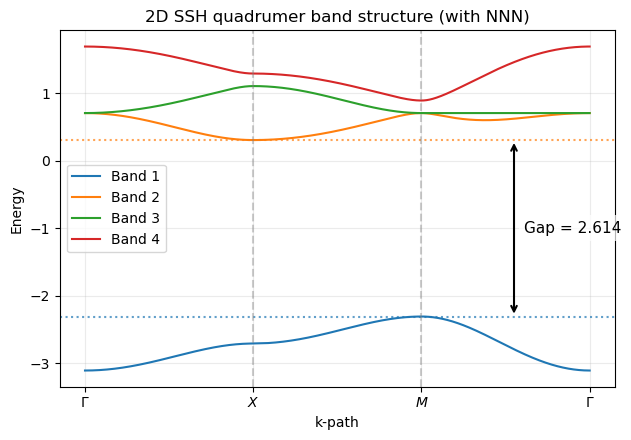


Diagnostics:
Number of bands        : 4
Global energy range    : [-3.107, 1.693]
Band 1 max             : -2.307
Band 2 min             : 0.307
Gap (Band 2 - Band 1)  : 2.614
Minimum direct gap (Γ–X–M–Γ scan): 0.000


In [2]:
# ============================================================
# 2D SSH MODEL (Fig. 1b, Nature Photonics disclination paper)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PART 1 — MODEL PARAMETERS
# ============================================================

t1 = -0.2
t2 = -1.0       
tnn = t2 / np.sqrt(2)
a = 1.0

print("Model parameters:")
print(f"t1  = {t1}")
print(f"t2  = {t2}")
print(f"tnn = {tnn:.3f}")

# ============================================================
# PART 2 — BLOCH HAMILTONIAN (2D SSH QUADRUMER)
# Site labeling:
#
#   2 —— 3
#   |    |
#   |    |
#   0 —— 1
#
# ============================================================

def H_k(kx, ky):
    H = np.zeros((4, 4), dtype=complex)

    ex = np.exp(-1j * kx * a)
    ey = np.exp(-1j * ky * a)

    # --------------------------------------------------------
    # Intra-cell hoppings (t1)
    # --------------------------------------------------------
    H[0, 1] = t1
    H[0, 2] = t1
    H[1, 3] = t1
    H[2, 3] = t1

    # --------------------------------------------------------
    # Inter-cell hoppings (t2)
    # --------------------------------------------------------
    H[1, 0] = t2 * ex
    H[2, 0] = t2 * ey
    H[3, 1] = t2 * ey
    H[3, 2] = t2 * ex

    # --------------------------------------------------------
    # Next-nearest-neighbour hoppings (tnn)
    # Diagonals: (0 ↔ 3) and (1 ↔ 2)
    # --------------------------------------------------------
    H[3, 0] = tnn * ex * ey
    H[1, 2] = tnn * np.conj(ey) * ex

    # --------------------------------------------------------
    # Hermitian conjugate (added ONCE) for Hermiticity
    # --------------------------------------------------------
    H = H + H.conj().T

    return H

# ============================================================
# PART 3 — HIGH-SYMMETRY K-PATH (Γ–X–M–Γ)
# ============================================================

Nk = 3000    # Number of k-points per segment

G = np.array([0.0, 0.0])
X = np.array([np.pi / a, 0.0])
M = np.array([np.pi / a, np.pi / a])

def interpolate(k1, k2, N):
    return np.linspace(k1, k2, N, endpoint=False)

k_path = np.vstack([
    interpolate(G, X, Nk),
    interpolate(X, M, Nk),
    interpolate(M, G, Nk),
])

k_labels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
k_label_positions = [0, Nk, 2 * Nk, 3 * Nk]

# ============================================================
# PART 4 — BAND STRUCTURE CALCULATION
# ============================================================

bands = np.zeros((len(k_path), 4))

for i, (kx, ky) in enumerate(k_path):
    bands[i] = np.linalg.eigvalsh(H_k(kx, ky))

# ============================================================
# PART 5 — PLOT
# ============================================================

plt.figure(figsize=(6.5, 4.5))

# Use a colormap for different band colors
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(4)]
for n in range(4):
    plt.plot(bands[:, n], color=colors[n], lw=1.5, label=f"Band {n+1}")

# Calculate gap between minimum of band 2 and maximum of band 1
band1_max = bands[:, 0].max()
band2_min = bands[:, 1].min()
gap_value = band2_min - band1_max

# Add horizontal dotted lines at band 1 max and band 2 min
plt.axhline(y=band1_max, color=colors[0], linestyle=':', linewidth=1.5, alpha=0.7)
plt.axhline(y=band2_min, color=colors[1], linestyle=':', linewidth=1.5, alpha=0.7)

# Add gap visualization and annotate inside the graph
x_pos = len(k_path) * 0.85  # Position at 85% of x-axis
plt.annotate('', xy=(x_pos, band2_min), xytext=(x_pos, band1_max),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
plt.text(x_pos + len(k_path)*0.02, (band1_max + band2_min)/2, 
         f'Gap = {gap_value:.3f}', fontsize=11, va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Vertical lines at high-symmetry points
for xc in k_label_positions[1:-1]:
    plt.axvline(xc, color="gray", linestyle="--", alpha=0.4)

plt.xticks(k_label_positions, k_labels)
plt.ylabel("Energy")
plt.xlabel("k-path")
plt.title("2D SSH quadrumer band structure (with NNN)")
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================
# PART 6 — DIAGNOSTICS
# ============================================================

print("\nDiagnostics:")
print(f"Number of bands        : {bands.shape[1]}")
print(f"Global energy range    : [{bands.min():.3f}, {bands.max():.3f}]")
print(f"Band 1 max             : {band1_max:.3f}")
print(f"Band 2 min             : {band2_min:.3f}")
print(f"Gap (Band 2 - Band 1)  : {gap_value:.3f}")
print(f"Minimum direct gap (Γ–X–M–Γ scan): "
      f"{np.min(bands[:, 2] - bands[:, 1]):.3f}")


Initializing eigensolver data
Computing 6 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 100 x 100 x 1.
Solving for 6 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0.32,0.32,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.32,-0.32,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
     cylinder, center = (-0.32,0.32,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
     cylinder, center = (-0.32,-0.32,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
Geometric object tree has depth 3 and 16 object nodes (vs. 4 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
64 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.0238095

IndexError: list index out of range

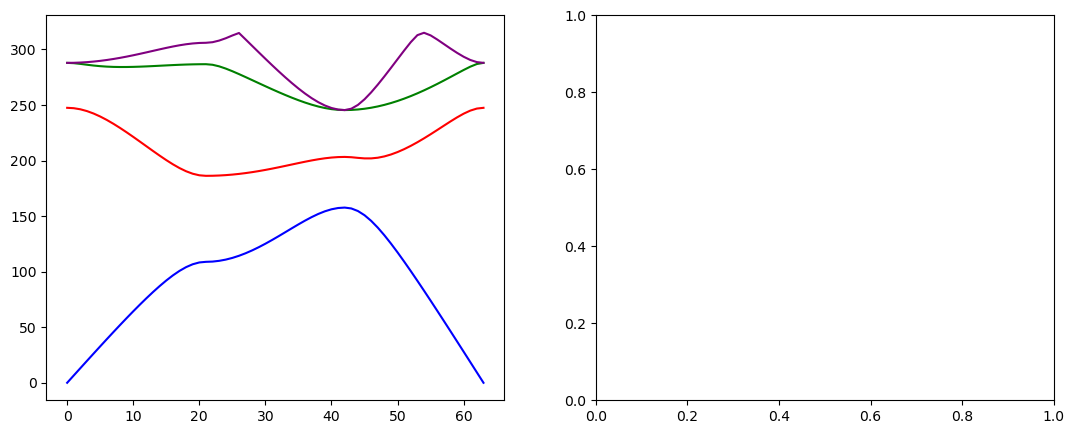

In [3]:
import meep as mp
from meep import mpb
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Parameters for both cases
# -------------------------------------------------
a_values_nm = [500.0, 50000.0]  # lattice constants in nanometers
a = 1.0  # MPB uses a=1 normalized units
r = 0.2 * a  # hole radius
eps_bg = 3.42**2
offset = 0.32 * a  # offset for all cases
num_bands = 6
resolution = 100

# k-point path Γ–X–M–Γ
Gamma = mp.Vector3(0, 0)
X = mp.Vector3(0.5, 0)
M = mp.Vector3(0.5, 0.5)
k_points = mp.interpolate(20, [Gamma, X, M, Gamma])
k_axis = np.arange(len(k_points))
tick_positions = [0, (len(k_points) - 1) // 3, 2 * (len(k_points) - 1) // 3, len(k_points) - 1]

# Geometry (same for both cases)
geometry = [
    mp.Cylinder(radius=r, height=mp.inf, center=mp.Vector3(+offset, +offset), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r, height=mp.inf, center=mp.Vector3(+offset, -offset), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r, height=mp.inf, center=mp.Vector3(-offset, +offset), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r, height=mp.inf, center=mp.Vector3(-offset, -offset), material=mp.Medium(epsilon=1.0)),
]

lattice = mp.Lattice(size=mp.Vector3(1, 1))

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for idx, a_nm in enumerate(a_values_nm):
    # Speed of light and conversion factor from normalized freq (ωa/2πc) to THz
    c0 = 299_792_458.0  # m/s
    freq_scale_THz = (c0 / (a_nm * 1e-9)) / 1e12  # THz per normalized frequency unit

    # MPB solver
    ms = mpb.ModeSolver(
        geometry_lattice=lattice,
        geometry=geometry,
        k_points=k_points,
        resolution=resolution,
        num_bands=num_bands,
        default_material=mp.Medium(epsilon=eps_bg)
    )

    ms.run_te()

    bands = np.array(ms.all_freqs)
    bands_THz = bands * freq_scale_THz

    # Calculate gap between band 1 and band 2
    band1_max = bands_THz[:, 0].max()
    band2_min = bands_THz[:, 1].min()
    gap_12 = band2_min - band1_max

    # Plot photonic band structure in THz
    ax = axs[idx]
    colors = plt.cm.tab10(np.linspace(0, 1, num_bands))
    for n in range(num_bands):
        ax.plot(k_axis, bands_THz[:, n], color=colors[n], linewidth=1.8, label=f"Band {n+1}")

    # Add horizontal dotted lines at band 1 max and band 2 min
    ax.axhline(y=band1_max, color='blue', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axhline(y=band2_min, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

    # Add gap visualization between Band 1 and Band 2 when a true gap exists
    x_pos = int(0.85 * (len(k_points) - 1))
    if gap_12 > 0:
        ax.annotate('', xy=(x_pos, band2_min), xytext=(x_pos, band1_max),
                    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
        ax.text(x_pos + 1.0, 0.5 * (band1_max + band2_min),
                f'Gap = {gap_12:.3f} THz', fontsize=9, va='center')
        ax.fill_between(k_axis, band1_max, band2_min, where=band2_min >= band1_max,
                        color='gray', alpha=0.08)

    xlabels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(xlabels)
    for xpos in tick_positions:
        ax.axvline(x=xpos, color='0.8', linestyle='--', linewidth=0.8, zorder=0)
    ax.set_xlim(k_axis[0], k_axis[-1])
    ax.set_ylabel("Frequency (THz)")
    ax.set_xlabel("k-path")
    ax.set_title(f"Photonic band structure (a = {a_nm:.0f} nm)")
    ax.legend(loc="best")
    ax.grid(True)

plt.tight_layout()
plt.show()

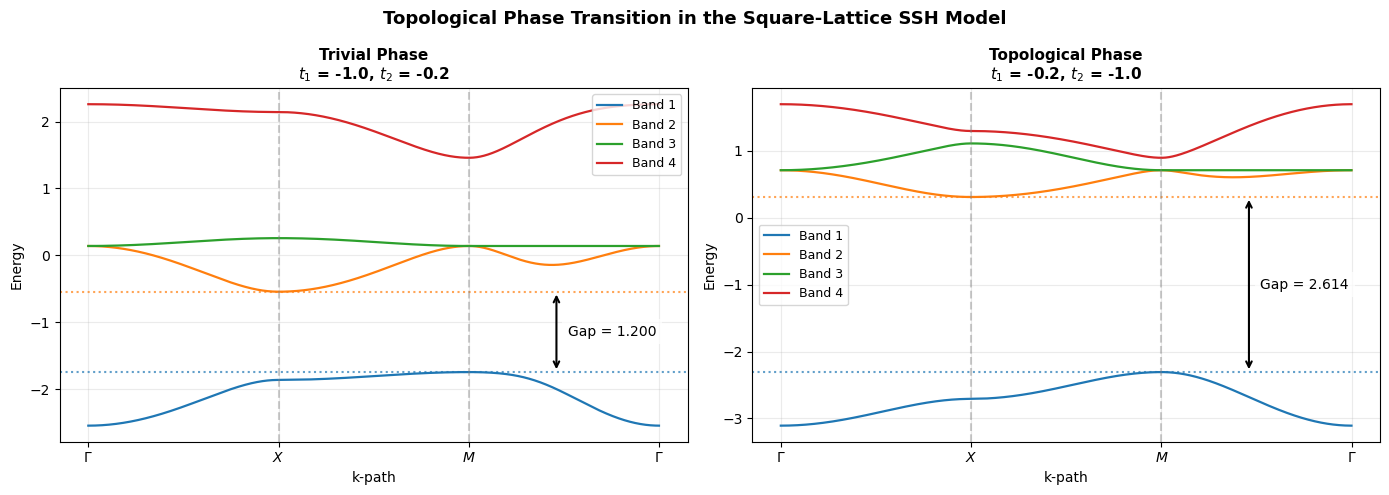


Topological comparison:
Trivial:    t1 = -1.0, t2 = -0.2, tnn = -0.141
Topological: t1 = -0.2, t2 = -1.0, tnn = -0.707


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# TOPOLOGICAL PHASE TRANSITION IN THE SQUARE-LATTICE SSH MODEL
# ============================================================
# Compare trivial and topological phases by swapping intra-cell
# and inter-cell hopping strengths.
# ============================================================

# ------------------------------------------------------------
# Square-lattice SSH parameters
# ------------------------------------------------------------
a = 1.0
Nk = 800

# Trivial phase: strong intra-cell coupling
t1_trivial = -1.0
t2_trivial = -0.2

# Topological phase: strong inter-cell coupling
t1_topo = -0.2
t2_topo = -1.0

# ------------------------------------------------------------
# Bloch Hamiltonian for the square SSH quadrumer
# Same 4-site basis as the existing band-structure cell
# ------------------------------------------------------------

def H_k_topo_square(kx, ky, t1, t2, tnn):
    H = np.zeros((4, 4), dtype=complex)

    ex = np.exp(-1j * kx * a)
    ey = np.exp(-1j * ky * a)

    # Intra-cell hoppings
    H[0, 1] = t1
    H[0, 2] = t1
    H[1, 3] = t1
    H[2, 3] = t1

    # Inter-cell hoppings
    H[1, 0] = t2 * ex
    H[2, 0] = t2 * ey
    H[3, 1] = t2 * ey
    H[3, 2] = t2 * ex

    # Next-nearest-neighbour hoppings
    H[3, 0] = tnn * ex * ey
    H[1, 2] = tnn * np.conj(ey) * ex

    H = H + H.conj().T
    return H

# Use the same NNN scaling as the existing SSH model
tnn_trivial = t2_trivial / np.sqrt(2)
tnn_topo = t2_topo / np.sqrt(2)

# ------------------------------------------------------------
# High-symmetry k-path (Gamma-X-M-Gamma)
# ------------------------------------------------------------
G = np.array([0.0, 0.0])
X = np.array([np.pi / a, 0.0])
M = np.array([np.pi / a, np.pi / a])

def interpolate(k1, k2, N):
    return np.linspace(k1, k2, N, endpoint=False)

k_path = np.vstack([
    interpolate(G, X, Nk),
    interpolate(X, M, Nk),
    interpolate(M, G, Nk),
])

k_labels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
k_label_positions = [0, Nk, 2 * Nk, 3 * Nk]

# ------------------------------------------------------------
# Compute both phases
# ------------------------------------------------------------
phases = [
    (t1_trivial, t2_trivial, tnn_trivial, "Trivial Phase"),
    (t1_topo, t2_topo, tnn_topo, "Topological Phase"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (t1, t2, tnn, phase_name) in zip(axes, phases):
    bands = np.zeros((len(k_path), 4))
    for i, (kx, ky) in enumerate(k_path):
        bands[i] = np.linalg.eigvalsh(H_k_topo_square(kx, ky, t1, t2, tnn))

    colors = [plt.get_cmap('tab10')(i) for i in range(4)]
    for n in range(4):
        ax.plot(bands[:, n], color=colors[n], lw=1.6, label=f'Band {n + 1}')

    band1_max = bands[:, 0].max()
    band2_min = bands[:, 1].min()
    gap_value = band2_min - band1_max

    ax.axhline(y=band1_max, color=colors[0], linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axhline(y=band2_min, color=colors[1], linestyle=':', linewidth=1.5, alpha=0.7)

    x_pos = len(k_path) * 0.82
    ax.annotate('', xy=(x_pos, band2_min), xytext=(x_pos, band1_max),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(x_pos + len(k_path) * 0.02, (band1_max + band2_min) / 2,
            f'Gap = {gap_value:.3f}' if gap_value > 0 else f'Gap = {gap_value:.3f} (INVERTED)',
            fontsize=10, va='center',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

    for xc in k_label_positions[1:-1]:
        ax.axvline(xc, color='gray', linestyle='--', alpha=0.4)

    ax.set_xticks(k_label_positions)
    ax.set_xticklabels(k_labels)
    ax.set_ylabel('Energy')
    ax.set_xlabel('k-path')
    ax.set_title(f'{phase_name}\n' + rf'$t_1$ = {t1:.1f}, $t_2$ = {t2:.1f}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=9)

plt.suptitle('Topological Phase Transition in the Square-Lattice SSH Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTopological comparison:')
print(f'Trivial:    t1 = {t1_trivial:.1f}, t2 = {t2_trivial:.1f}, tnn = {tnn_trivial:.3f}')
print(f'Topological: t1 = {t1_topo:.1f}, t2 = {t2_topo:.1f}, tnn = {tnn_topo:.3f}')
